In [2]:
#from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, v_measure_score
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster, dendrogram, linkage
%pip install tensorflow

#drive.mount("/content/gdrive")
route = '/content/gdrive/MyDrive/GIA/MAA'
#%cd $route
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Aplanar de (60000, 28, 28) a (60000, 784)
X_train = X_train.reshape(X_train.shape[0], -1).astype(float)
X_test  = X_test.reshape(X_test.shape[0], -1).astype(float)

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\pablo\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "c:\Users\pablo\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 248, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pablo\anaconda3\Lib\site-packages\pip\_internal\commands\install.py", line 362, in run
    resolver = self.make_resolver(
               ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pablo\anaconda3\Lib\site-packages\pip\_internal\cli\req_command.py", line 358, in make_resolver
    return pip._internal.resolution.resolvelib.resolver.Resolver(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\pablo\anaconda3\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 55, in __init__
    self.factory = Factory(
                   

Note: you may need to restart the kernel to use updated packages.


In [3]:
# X_train, y_train = mnist_reader.load_mnist('data/fashion', kind='train')
# X_test, y_test = mnist_reader.load_mnist('data/fashion', kind='t10k')

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)

X_train_norm = X_train / 255.0
print("\n=== Estadísticas (datos sin normalizar) ===")
print(f"Valor mínimo:      {X_train.min()}")
print(f"Valor máximo:      {X_train.max()}")
print(f"Media:             {X_train.mean():.2f}")
print(f"Desviación típica: {X_train.std():.2f}")

Forma de X_train: (60000, 784)
Forma de y_train: (60000,)

=== Estadísticas (datos sin normalizar) ===
Valor mínimo:      0.0
Valor máximo:      255.0
Media:             72.94
Desviación típica: 90.02


In [4]:
# Distribución de clases
unique, counts = np.unique(y_train, return_counts=True)
print("\nDistribución de clases:")
for i, c in zip(unique, counts):
    print(f"  Clase {i}: {c} muestras")


Distribución de clases:
  Clase 0: 6000 muestras
  Clase 1: 6000 muestras
  Clase 2: 6000 muestras
  Clase 3: 6000 muestras
  Clase 4: 6000 muestras
  Clase 5: 6000 muestras
  Clase 6: 6000 muestras
  Clase 7: 6000 muestras
  Clase 8: 6000 muestras
  Clase 9: 6000 muestras


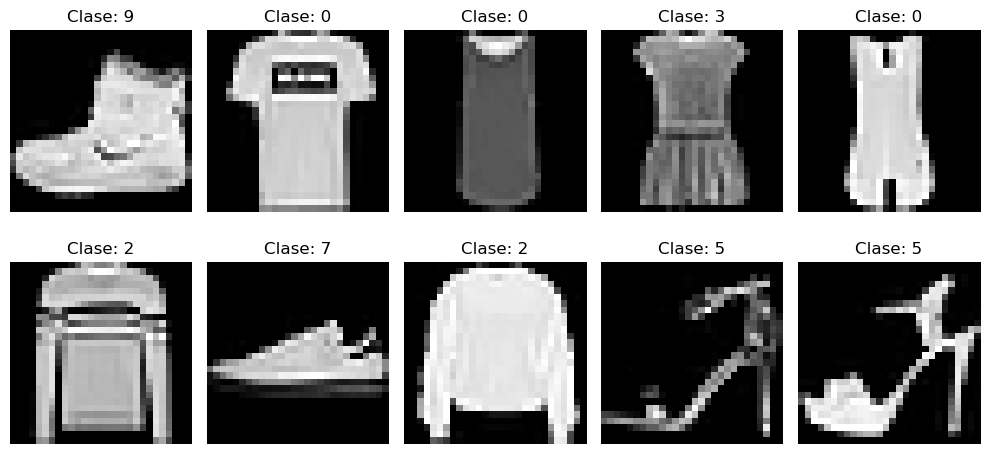

In [5]:

#Imágenes
fig , axes = plt.subplots(2, 5, figsize = (10,5))

for i,ax in  enumerate(axes.flat):
    ax.imshow(X_train_norm[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Clase: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

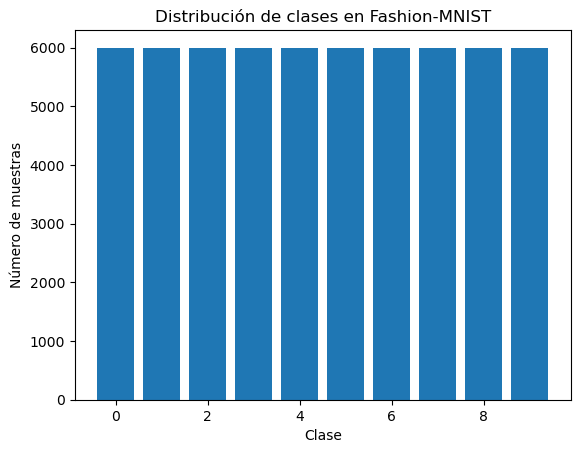

In [6]:
unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique, counts)
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.title("Distribución de clases en Fashion-MNIST")
plt.show()


In [7]:
#Normalización

X_train_norm = X_train / 255.0
#Resumen estadístico despues de normalizar
print(f"Valor mínimo:      {X_train_norm.min():.2f}")
print(f"Valor máximo:      {X_train_norm.max():.2f}")
print(f"Media:             {X_train_norm.mean():.3f}")
print(f"Desviación típica: {X_train_norm.std():.3f}")

Valor mínimo:      0.00
Valor máximo:      1.00
Media:             0.286
Desviación típica: 0.353


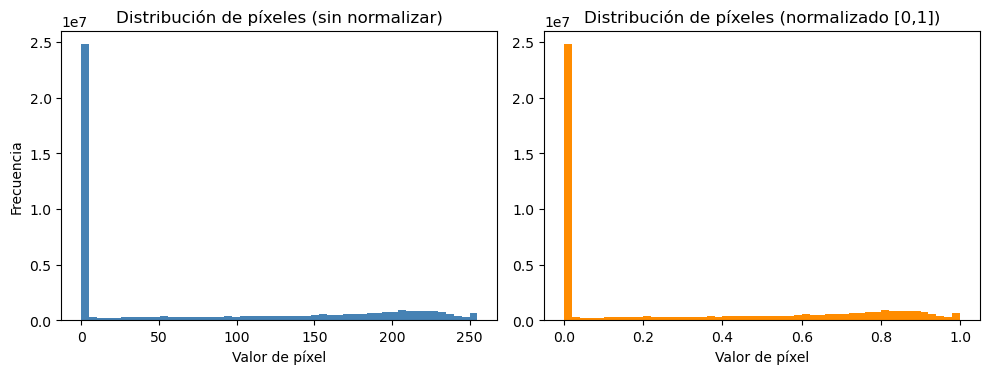

In [8]:
# Histograma de valores de píxel antes y después
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.flatten(), bins=50, color='steelblue')
axes[0].set_title("Distribución de píxeles (sin normalizar)")
axes[0].set_xlabel("Valor de píxel")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(X_train_norm.flatten(), bins=50, color='darkorange')
axes[1].set_title("Distribución de píxeles (normalizado [0,1])")
axes[1].set_xlabel("Valor de píxel")

plt.tight_layout()
plt.show()

In [9]:
#Identificación de valores atípicos

# Calculamos la norma L2 de cada imagen (suma total de intensidad).
# Imágenes con norma muy alta o muy baja pueden ser atípicas.
normas = np.linalg.norm(X_train_norm, axis=1)

media_norma = normas.mean()
std_norma   = normas.std()

In [10]:
# Consideramos atípica toda imagen que se aleje más de 3 desviaciones típicas
umbral_sup = media_norma + 3 * std_norma
umbral_inf = media_norma - 3 * std_norma

outliers_idx = np.where((normas > umbral_sup) | (normas < umbral_inf))[0]

print(f"\n=== Identificación de valores atípicos ===")
print(f"Media de normas:       {media_norma:.3f}")
print(f"Desviación típica:     {std_norma:.3f}")
print(f"Umbral superior (+3σ): {umbral_sup:.3f}")
print(f"Umbral inferior (-3σ): {umbral_inf:.3f}")
print(f"Imágenes atípicas encontradas: {len(outliers_idx)} "
      f"({len(outliers_idx)/len(X_train_norm)*100:.2f}% del total)")


=== Identificación de valores atípicos ===
Media de normas:       12.152
Desviación típica:     3.765
Umbral superior (+3σ): 23.448
Umbral inferior (-3σ): 0.856
Imágenes atípicas encontradas: 0 (0.00% del total)


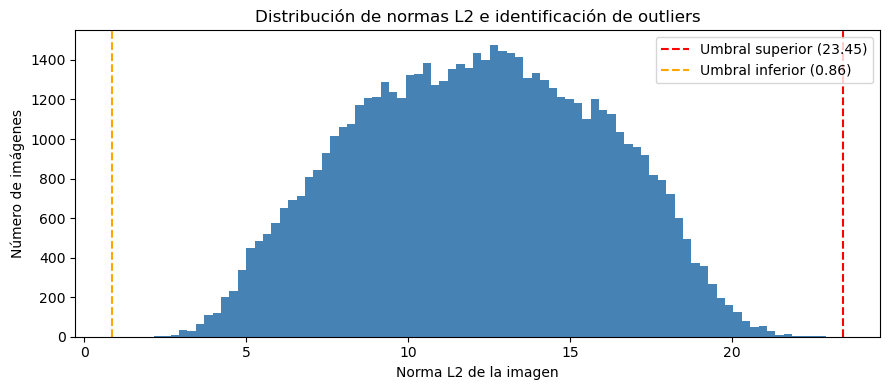

In [12]:
# Distribución de normas con umbrales
plt.figure(figsize=(9, 4))
plt.hist(normas, bins=80, color='steelblue', edgecolor='none')
plt.axvline(umbral_sup, color='red',    linestyle='--', label=f'Umbral superior ({umbral_sup:.2f})')
plt.axvline(umbral_inf, color='orange', linestyle='--', label=f'Umbral inferior ({umbral_inf:.2f})')
plt.xlabel("Norma L2 de la imagen")
plt.ylabel("Número de imágenes")
plt.title("Distribución de normas L2 e identificación de outliers")
plt.legend()
plt.tight_layout()
plt.show()

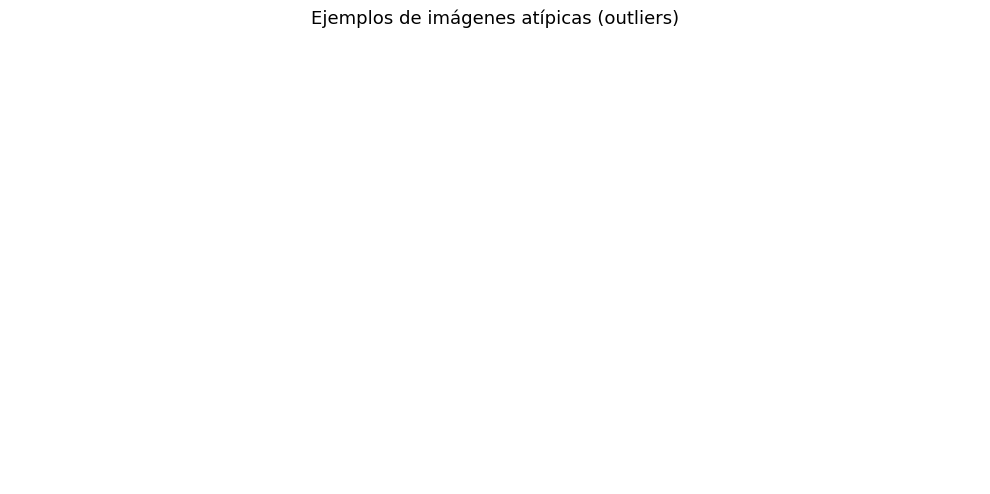

In [13]:

# Mostramos algunos ejemplos de imágenes atípicas
n_mostrar = min(10, len(outliers_idx))
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    if i < n_mostrar:
        ax.imshow(X_train_norm[outliers_idx[i]].reshape(28, 28), cmap='gray')
        ax.set_title(f"Norma: {normas[outliers_idx[i]]:.2f}\nClase: {y_train[outliers_idx[i]]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Ejemplos de imágenes atípicas (outliers)", fontsize=13)
plt.tight_layout()
plt.show()

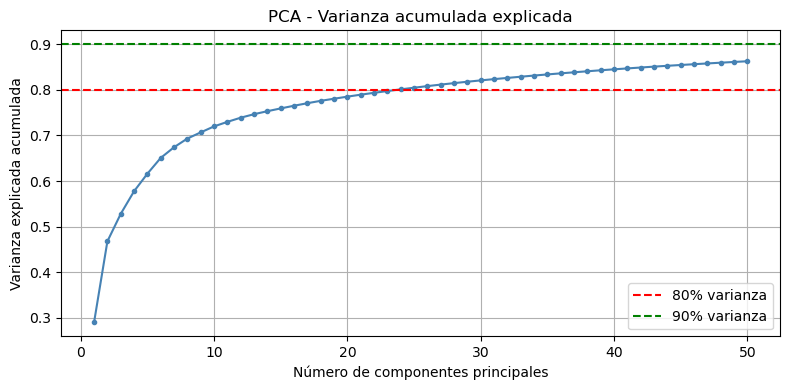

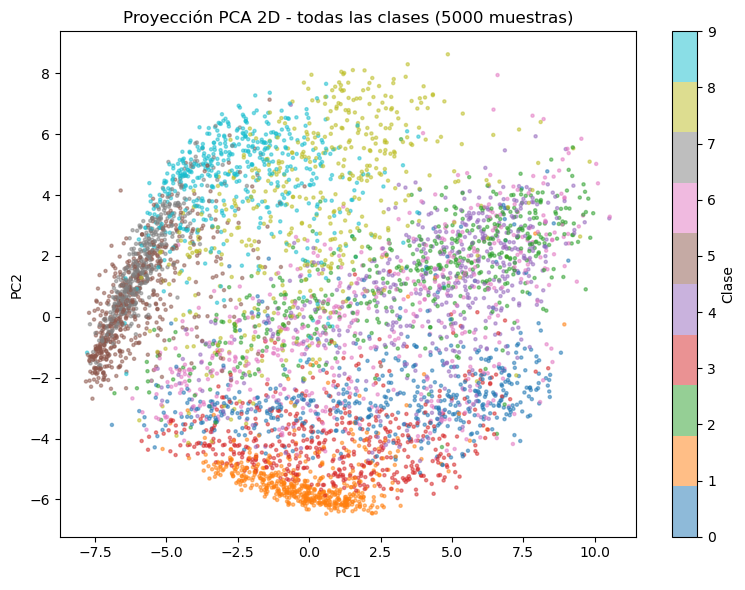

In [14]:
#Reducción de dimensionalidad
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_norm)

varianza_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 51), varianza_acum, marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.80, color='red',   linestyle='--', label='80% varianza')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% varianza')
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA - Varianza acumulada explicada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Muestra reducida para visualizar
np.random.seed(42)
idx_viz = np.random.choice(len(X_train_pca), 5000, replace=False)
X_viz   = X_train_pca[idx_viz]
y_viz   = y_train[idx_viz]

# Proyección 2D (PC1 y PC2)
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_viz)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=y_viz, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, label='Clase')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA 2D - todas las clases (5000 muestras)")
plt.tight_layout()
plt.show()

In [15]:
n_80 = np.argmax(varianza_acum >= 0.80) + 1
n_90 = np.argmax(varianza_acum >= 0.90) + 1
print(f"\nComponentes necesarios para explicar el 80% de varianza: {n_80}")
print(f"Componentes necesarios para explicar el 90% de varianza: {n_90}")
print(f"Varianza explicada total con 50 componentes: {varianza_acum[-1]:.3f}")


Componentes necesarios para explicar el 80% de varianza: 24
Componentes necesarios para explicar el 90% de varianza: 1
Varianza explicada total con 50 componentes: 0.863


# Modelos

In [16]:
k_list = range(2,15)
distortions_random = []
silhouette_random = []
v_measure_random = []

distortions_pp = []
silhouette_pp = []
v_measure_pp = []

np.random.seed(42)
sample_idx = np.random.choice(len(X_train_pca), 500, replace=False)

for k in k_list:
    # K-Means random
    model_random = KMeans(n_clusters=k, init='random', n_init = 5, max_iter=100)
    model_random.fit(X_train_pca)
    label_random = model_random.predict(X_train_pca)
    distortions_random.append(model_random.inertia_)
    silhouette_random.append(silhouette_score(X_train_pca[sample_idx], label_random[sample_idx]))
    v_measure_random.append(v_measure_score(y_train, label_random))

    # K-Means++
    model_pp = KMeans(n_clusters=k, init='k-means++',n_init = 5, max_iter=100)
    model_pp.fit(X_train_pca)
    label_pp = model_pp.predict(X_train_pca)
    distortions_pp.append(model_pp.inertia_)
    silhouette_pp.append(silhouette_score(X_train_pca[sample_idx], label_pp[sample_idx]))
    v_measure_pp.append(v_measure_score(y_train, label_pp))



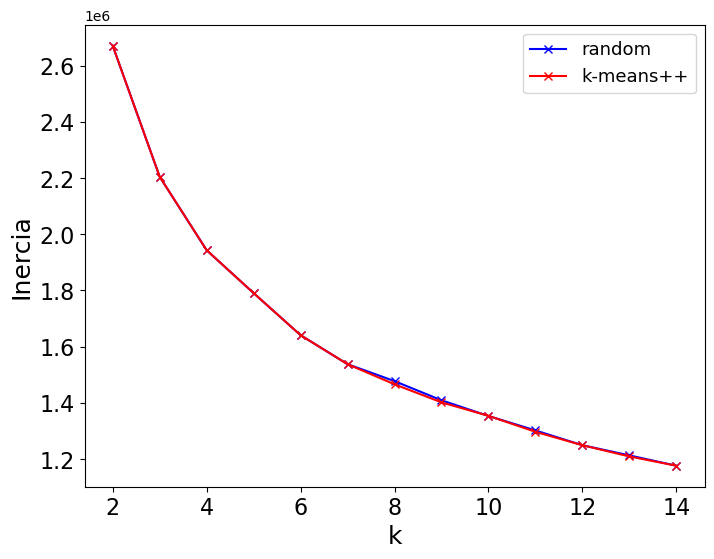

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, distortions_random, "bx-", label="random")
plt.plot(k_list, distortions_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("Inercia", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=16)
plt.setp(plt.gca().get_yticklabels(), fontsize=16)
plt.show()

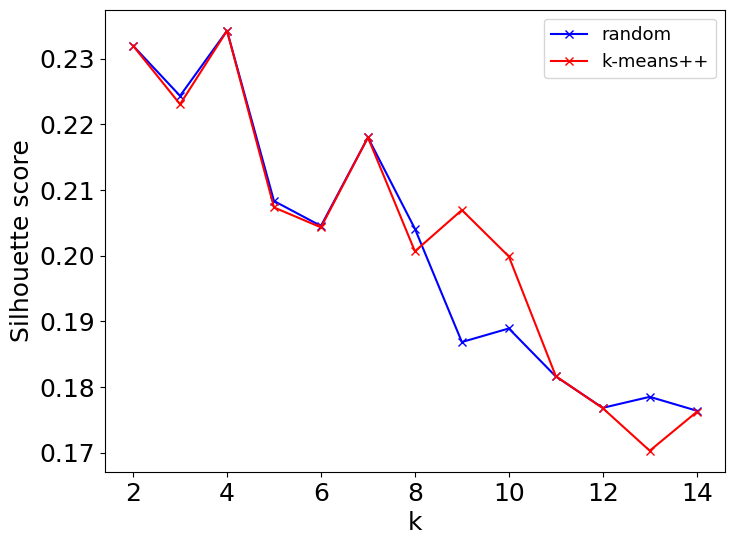

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, silhouette_random, "bx-", label="random")
plt.plot(k_list, silhouette_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("Silhouette score", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

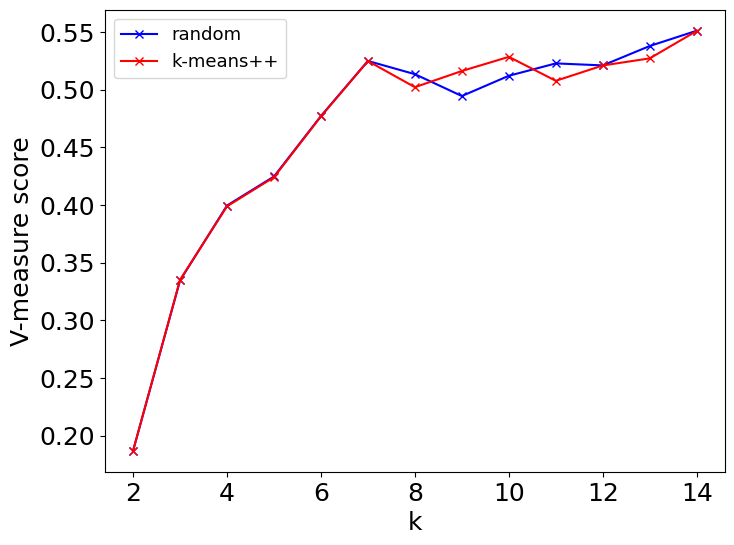

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(k_list, v_measure_random, "bx-", label="random")
plt.plot(k_list, v_measure_pp,     "rx-", label="k-means++")
plt.xlabel("k", fontsize=18)
plt.ylabel("V-measure score", fontsize=18)
plt.legend(fontsize=13)
plt.setp(plt.gca().get_xticklabels(), fontsize=18)
plt.setp(plt.gca().get_yticklabels(), fontsize=18)
plt.show()

## DBSCAN


grupos detectados:  8
datos clasificados como ruido:  2107


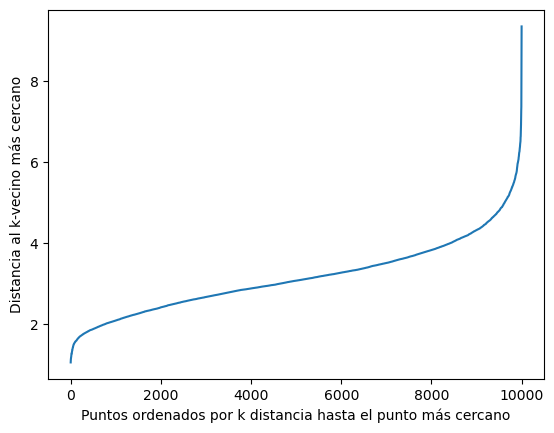

In [27]:
np.random.seed(42)
n_muestra_dbscan = 10000
idx_dbscan = np.random.choice(len(X_train_pca), n_muestra_dbscan, replace=False)
X_dbscan = X_train_pca[idx_dbscan]
y_dbscan = y_train[idx_dbscan]
n, dim = X_train_pca.shape
MinPts = 10

neighbors = NearestNeighbors(n_neighbors=MinPts)
neighbors.fit(X_dbscan)
distances, indices = neighbors.kneighbors(X_dbscan)
distances = np.sort(distances[:, MinPts-1])

plt.plot(distances)
plt.xlabel("Puntos ordenados por k distancia hasta el punto más cercano")
plt.ylabel("Distancia al k-vecino más cercano")

clustering = DBSCAN(eps = 3.3, min_samples= MinPts).fit(X_dbscan)
n_c = np.max(clustering.labels_)+1
print("grupos detectados: ",n_c)
print("datos clasificados como ruido: ", sum(clustering.labels_ == -1))

## Jerarquico

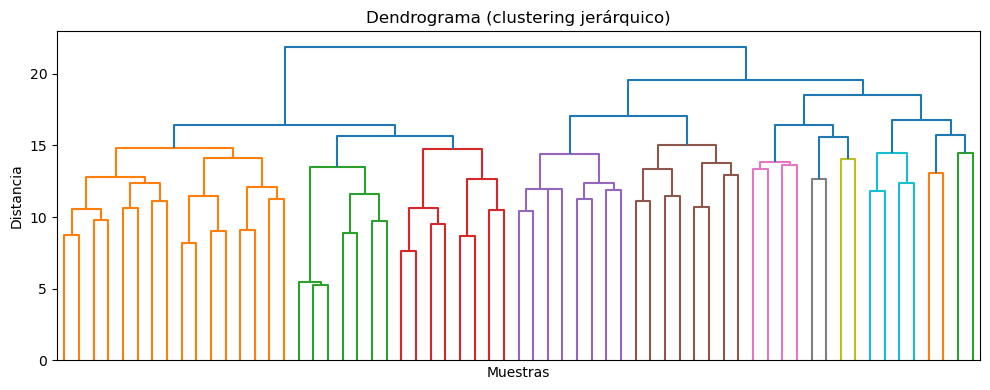

Grupos obtenidos: 10
Tamaño de cada grupo: [ 967  204   79 1406 2890 1513  426  411  682 1422]


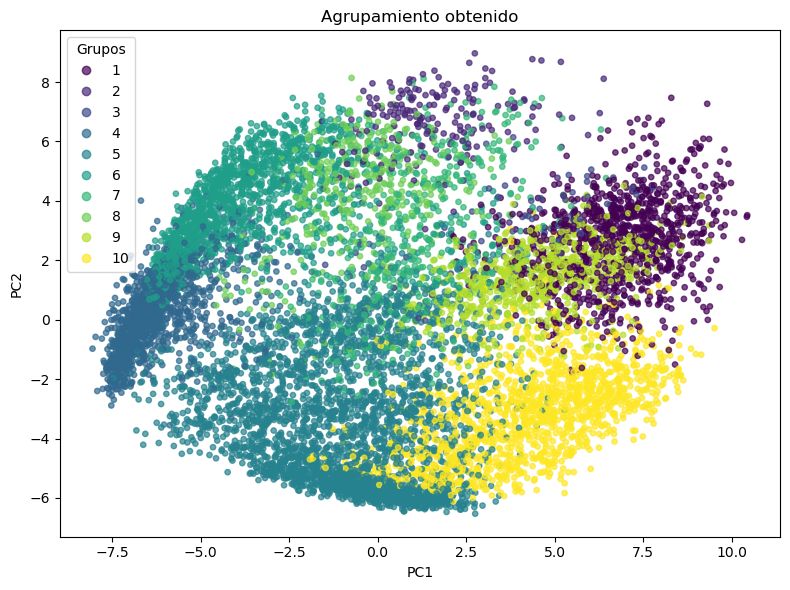

In [21]:
k = 10
np.random.seed(42)
n_muestra = 10000
idx_muestra = np.random.choice(len(X_train_pca), n_muestra, replace=False)
X_jerarquico = X_train_pca[idx_muestra]
y_jerarquico = y_train[idx_muestra]

dist = pdist(X_jerarquico)
linkage_matrix = linkage(dist, method="complete")

# Dendrograma (truncado para que sea legible)
plt.figure(figsize=(10, 4))
dendrogram(linkage_matrix, truncate_mode="level", p=5,
           no_labels=True)
plt.title("Dendrograma (clustering jerárquico)")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


# fcluster con criterion='maxclust' para elegir número de grupos
etiquetas_jerarquico = fcluster(linkage_matrix, k, criterion='maxclust')

print(f"Grupos obtenidos: {len(np.unique(etiquetas_jerarquico))}")
print(f"Tamaño de cada grupo: {np.unique(etiquetas_jerarquico, return_counts=True)[1]}")

# Visualización del resultado con PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_viz = pca_2d.fit_transform(X_jerarquico)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_viz[:, 0], X_viz[:, 1],
                      c=etiquetas_jerarquico, cmap='viridis', s=15, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Grupos")
plt.title("Agrupamiento obtenido")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## GMM

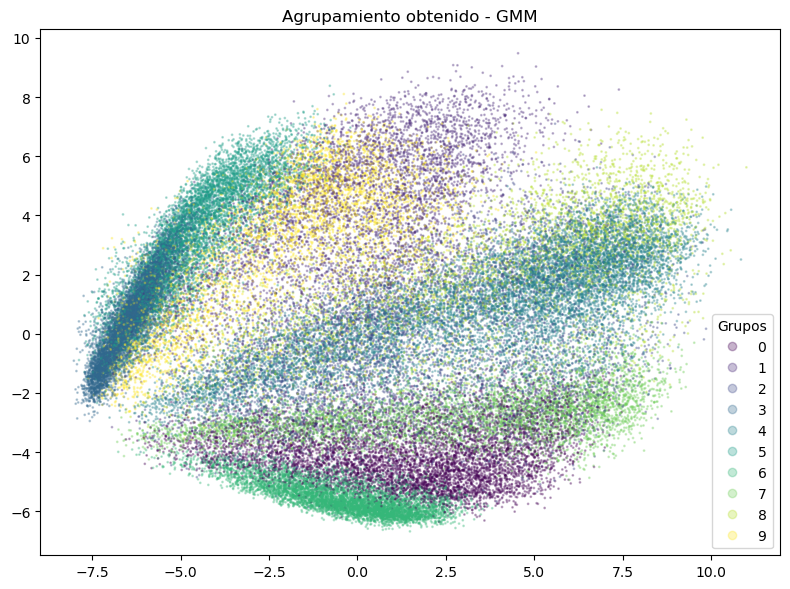

In [22]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X_train_pca)
labels_gmm = gmm.predict(X_train_pca)

# Visualización
pca_2d = PCA(n_components=2, random_state=42)
X_viz = pca_2d.fit_transform(X_train_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_viz[:, 0], X_viz[:, 1],
                      c=labels_gmm, cmap='viridis', s=1, alpha=0.3)
plt.legend(*scatter.legend_elements(), title="Grupos")
plt.title("Agrupamiento obtenido - GMM")
plt.tight_layout()
plt.show()

## Evaluación

Método                  Silueta  V-measure        ARI
-------------------------------------------------------
K-Means random           0.1764     0.5510     0.3885     0.5861
K-Means++                0.1762     0.5508     0.3881     0.5859
GMM                      0.0775     0.5720     0.3924     0.5679
Jerárquico               0.1376     0.4513     0.2512     0.4207
DBSCAN                   0.0103     0.0629     0.0061

  DBSCAN - Clusters encontrados: 8
  DBSCAN - Puntos como ruido:     2107


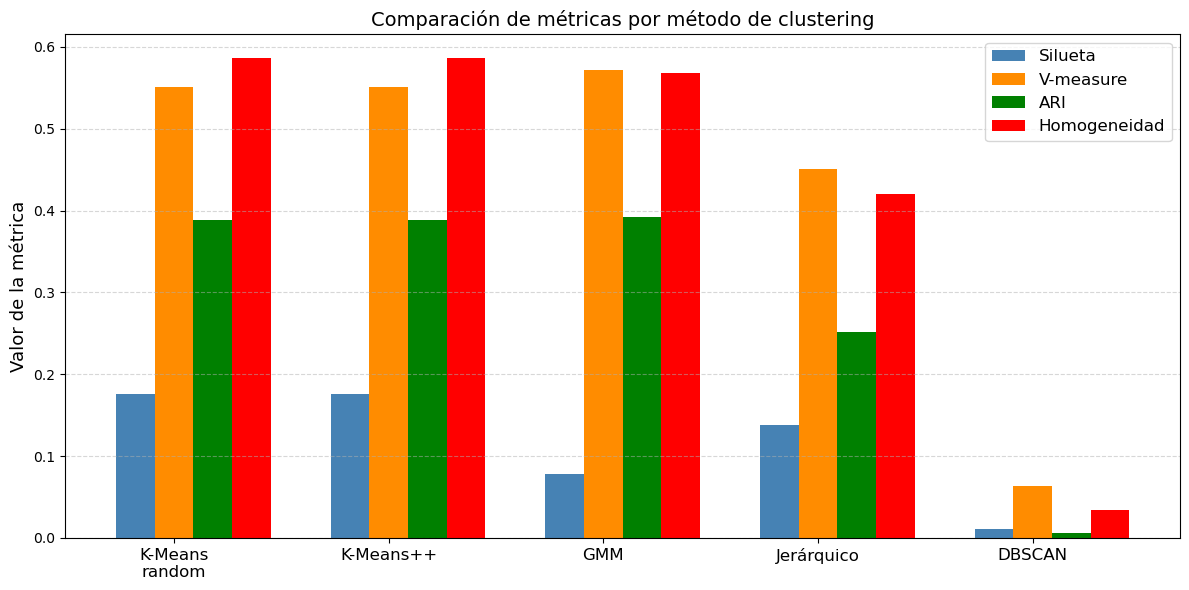

In [31]:
from sklearn.metrics import adjusted_rand_score, homogeneity_score

model_random_final = KMeans(n_clusters=k, init='random',
                             random_state=42, n_init=3, max_iter=100)
model_random_final.fit(X_train_pca)
label_random_final = model_random_final.predict(X_train_pca)

model_pp_final = KMeans(n_clusters=k, init='k-means++',
                         random_state=42, n_init=3, max_iter=100)
model_pp_final.fit(X_train_pca)
label_pp_final = model_pp_final.predict(X_train_pca)

np.random.seed(42)
sample_idx = np.random.choice(len(X_train_pca), 500, replace=False)

# Nota: label_random y label_pp son los del último k del bucle,
# así que hay que usar el k_optimo por separado si no lo hicisteis ya
y_muestra = y_train[idx_muestra]

metodos = {
    'K-Means random': (label_random, y_train,   X_train_pca,  sample_idx),
    'K-Means++':      (label_pp,     y_train,   X_train_pca,  sample_idx),
    'GMM':            (labels_gmm,   y_train,   X_train_pca,  sample_idx),
    'Jerárquico':     (etiquetas_jerarquico-1, y_muestra, X_jerarquico,
                       np.random.choice(len(X_jerarquico), 200, replace=False)),
}

print(f"{'Método':<20} {'Silueta':>10} {'V-measure':>10} {'ARI':>10}")
print("-" * 55)

for nombre, (labels, y_real, X, s_idx) in metodos.items():
    sil = silhouette_score(X[s_idx], labels[s_idx])
    vm  = v_measure_score(y_real, labels)
    ari = adjusted_rand_score(y_real, labels)
    hm = homogeneity_score(y_real, labels)
    print(f"{nombre:<20} {sil:>10.4f} {vm:>10.4f} {ari:>10.4f} {hm:>10.4f}")

# DBSCAN por separado por el ruido
mask = clustering.labels_ != -1

sample_dbscan = np.random.choice(np.where(mask)[0], min(500, mask.sum()), replace=False)
sil_db = silhouette_score(X_dbscan[sample_dbscan], clustering.labels_[sample_dbscan])
vm_db  = v_measure_score(y_dbscan[mask], clustering.labels_[mask])   # ✅ y_dbscan en lugar de y_train
ari_db = adjusted_rand_score(y_dbscan[mask], clustering.labels_[mask])  # ✅
hm_db = homogeneity_score(y_dbscan[mask], clustering.labels_[mask])
print(f"{'DBSCAN':<20} {sil_db:>10.4f} {vm_db:>10.4f} {ari_db:>10.4f}")
print(f"\n  DBSCAN - Clusters encontrados: {len(np.unique(clustering.labels_[mask]))}")
print(f"  DBSCAN - Puntos como ruido:     {(clustering.labels_ == -1).sum()}")

# ================================================================
# GRÁFICA COMPARATIVA
# ================================================================

nombres_metodos = ['K-Means\nrandom', 'K-Means++', 'GMM', 'Jerárquico', 'DBSCAN']
siluetas, vmeasures, aris, hms = [], [], [], []

for nombre, (labels, y_real, X, s_idx) in metodos.items():
    siluetas.append(silhouette_score(X[s_idx], labels[s_idx]))
    vmeasures.append(v_measure_score(y_real, labels))
    aris.append(adjusted_rand_score(y_real, labels))
    hms.append(homogeneity_score(y_real, labels))

siluetas.append(sil_db)
vmeasures.append(vm_db)
aris.append(ari_db)
hms.append(hm_db)

x = np.arange(len(nombres_metodos))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, siluetas,  width, label='Silueta',   color='steelblue')
ax.bar(x,         vmeasures, width, label='V-measure', color='darkorange')
ax.bar(x + width, aris,      width, label='ARI',       color='green')
ax.bar(x + width * 2,hms,    width,label = "Homogeneidad", color = "red")
ax.set_xticks(x)
ax.set_xticklabels(nombres_metodos, fontsize=12)
ax.set_ylabel("Valor de la métrica", fontsize=13)
ax.set_title("Comparación de métricas por método de clustering", fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


